# ConvNeXt-Tiny refinement

Picking up from `Augmentation.ipynb` where we tried resnet18 / efficientnet_b0 / convnext_tiny and convnext_tiny came out on top.

Things changed from the baseline training loop:
- a couple extra augmentations (perspective, coarse dropout)
- bigger regression head with dropout
- SmoothL1 loss (Huber) instead of MSE
- layer-wise lr decay on the backbone
- warmup + cosine schedule (was just cosine before)
- EMA of weights, pick whichever (raw vs EMA) wins on val each epoch
- TTA at test time

## Setup

Loading the dataset directly from HF Hub (`JX128/image2GPS_project_dataset_grouped`) instead of shuttling it through Drive - much faster and cached locally on first use. Drive is only mounted so we can save the final checkpoint there.

In [ ]:
!pip -q install timm albumentations datasets

In [ ]:
import os, math, time, copy, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
from datasets import load_dataset
import cv2
import timm

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")

Using: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

#DRIVE_PATH = "/content/drive/Shareddrives/CIS5190_final_project/processed_dataset_grouped"
#LOCAL_PATH = "/content/dataset"

CKPT_DIR = "/content/drive/Shareddrives/CIS5190_final_project/checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
dataset = load_dataset("JX128/image2GPS_project_dataset_grouped")
print(dataset)

In [ ]:
import pandas as pd
from PIL import Image
from tqdm import tqdm

CACHE_DIR = "/content/dataset_resized"

if not os.path.exists(CACHE_DIR):
    os.makedirs(CACHE_DIR)
    for split in ["train", "validation", "test"]:
        split_dir = os.path.join(CACHE_DIR, split)
        os.makedirs(split_dir)
        rows = []
        for i, ex in enumerate(tqdm(dataset[split], desc=split)):
            fname = f"{i:05d}.jpg"
            img = ex["image"].convert("RGB")
            img.thumbnail((512, 512))
            img.save(os.path.join(split_dir, fname), quality=90)
            rows.append({
                "file_name": fname,
                "Latitude": ex["Latitude"],
                "Longitude": ex["Longitude"],
            })
        pd.DataFrame(rows).to_csv(os.path.join(split_dir, "metadata.csv"), index=False)
    print("resized cache built at", CACHE_DIR)
else:
    print("resized cache already exists, skipping")

# free the big HF dataset from memory (optional but helps on low-RAM VMs)
del dataset
import gc; gc.collect()

dataset = load_dataset("imagefolder", data_dir=CACHE_DIR)
print(dataset)

test: 100%|██████████| 494/494 [02:02<00:00,  4.05it/s]


resized cache built at /content/dataset_resized


Resolving data files:   0%|          | 0/2305 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/495 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/495 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'Latitude', 'Longitude'],
        num_rows: 2304
    })
    validation: Dataset({
        features: ['image', 'Latitude', 'Longitude'],
        num_rows: 494
    })
    test: Dataset({
        features: ['image', 'Latitude', 'Longitude'],
        num_rows: 494
    })
})


## compute GPS normalization stats

In [ ]:

# normalization stats are computed on train only (avoid leaking val/test distribution)
train_lats = np.array(dataset["train"]["Latitude"], dtype=np.float64)
train_lons = np.array(dataset["train"]["Longitude"], dtype=np.float64)

lat_mean, lat_std = float(train_lats.mean()), float(train_lats.std())
lon_mean, lon_std = float(train_lons.mean()), float(train_lons.std())
print(f"lat: mean={lat_mean:.6f}  std={lat_std:.6f}")
print(f"lon: mean={lon_mean:.6f}  std={lon_std:.6f}")

def normalize_gps(lat, lon):
    return (lat - lat_mean) / lat_std, (lon - lon_mean) / lon_std

def denormalize_gps(lat_n, lon_n):
    return lat_n * lat_std + lat_mean, lon_n * lon_std + lon_mean

lat: mean=39.951684  std=0.000666
lon: mean=-75.191403  std=0.000665


## Augmentations

Mostly keeping the pipeline from `Augmentation.ipynb`. Sticking with 224x224 input. A couple small additions:

- added `Perspective` (small) and `CoarseDropout`. Perspective helps with phones being held at different tilts; CoarseDropout forces the model to not lean on any single region of the frame
- dropped hue jitter from 0.08 to 0.05. 0.08 can flip leaves between green and yellow which seemed a bit much for localization where plant color is actually a decent seasonal cue

In [ ]:
IMG_SIZE = 224
RESIZE_SIZE = 256

train_process = A.Compose([
    A.SmallestMaxSize(max_size=RESIZE_SIZE),
    A.RandomResizedCrop(size=(IMG_SIZE, IMG_SIZE), scale=(0.75, 1.0), ratio=(0.9, 1.1), p=1.0),
    A.Rotate(limit=12, p=0.4, border_mode=cv2.BORDER_REFLECT_101),
    # new: small perspective warps. handles tilt differences between collectors
    A.Perspective(scale=(0.02, 0.05), p=0.3, pad_mode=cv2.BORDER_REFLECT_101),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.3, hue=0.05, p=0.6),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.3),
    A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.3),
    A.RandomShadow(shadow_roi=(0, 0.2, 1, 1), num_shadows_limit=(1, 2), p=0.2),
    A.ToGray(p=0.1),
    # new: coarse dropout. don't let the model lean on a single patch of the frame
    A.CoarseDropout(num_holes_range=(1, 3), hole_height_range=(16, 48), hole_width_range=(16, 48), p=0.3),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

val_test_process = A.Compose([
    A.SmallestMaxSize(max_size=RESIZE_SIZE),
    A.CenterCrop(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

/tmp/ipykernel_16224/3467425294.py:9: UserWarning: Argument(s) 'pad_mode' are not valid for transform Perspective
  A.Perspective(scale=(0.02, 0.05), p=0.3, pad_mode=cv2.BORDER_REFLECT_101),


In [ ]:
def make_fn(aug_process):
    def process_batch(batch):
        imgs = []
        for pil_img in batch["image"]:
            img_np = np.array(pil_img.convert("RGB"))
            pil_img.thumbnail((512, 512))
            img_np = np.array(pil_img)
            imgs.append(aug_process(image=img_np)["image"])

        lat = np.array(batch["Latitude"], dtype=np.float32)
        lon = np.array(batch["Longitude"], dtype=np.float32)
        lat_n, lon_n = normalize_gps(lat, lon)
        labels = torch.tensor(np.stack([lat_n, lon_n], axis=1), dtype=torch.float32)

        return {"pixel_values": torch.stack(imgs), "labels": labels}
    return process_batch

train_ds = dataset["train"].with_transform(make_fn(train_process))
val_ds   = dataset["validation"].with_transform(make_fn(val_test_process))
test_ds  = dataset["test"].with_transform(make_fn(val_test_process))

In [ ]:
# same batch size as baseline run
BATCH_SIZE = 32
NUM_WORKERS = 0

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

batch = next(iter(train_loader))
print(f"pixel_values: {batch['pixel_values'].shape}")
print(f"labels:       {batch['labels'].shape}")

pixel_values: torch.Size([32, 3, 224, 224])
labels:       torch.Size([32, 2])


## ConvNeXt-Tiny with a bigger regression head

The baseline used timm's default `num_classes=2`, which is literally one `Linear(768, 2)` on top of the global-pooled features. With only ~2 outputs a lot of the backbone's 768-dim feature vector goes unused. A two-layer MLP with BN + dropout gives the regressor a bit more flexibility without adding many parameters, and the dropout helps because our training set is pretty small.

In [ ]:
class ConvNextRegressor(nn.Module):
    def __init__(self, backbone_name="convnext_tiny.fb_in22k_ft_in1k", dropout=0.3):
        super().__init__()
        # num_classes=0 + global_pool='avg' -> get pooled features directly
        self.backbone = timm.create_model(backbone_name, pretrained=True, num_classes=0, global_pool="avg")
        feat_dim = self.backbone.num_features  # 768 for convnext_tiny
        self.head = nn.Sequential(
            nn.BatchNorm1d(feat_dim),
            nn.Dropout(dropout),
            nn.Linear(feat_dim, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, 2),
        )

    def forward(self, x):
        return self.head(self.backbone(x))

model = ConvNextRegressor().to(device)
print(f"Params: {sum(p.numel() for p in model.parameters()):,}")

Params: 28,019,042


## Layer-wise learning rate decay

Baseline used two learning rates: one for the whole backbone (`1e-4`) and one for the head (`1e-3`). That's already better than a single LR, but it still treats stem/stage0/stage1/stage2/stage3 as one thing. Early ConvNeXt stages mostly learn edges/colors which we don't really want to mess with - later stages do the semantic stuff where most of the task-specific adaptation should happen. LLRD just scales the LR per stage by `decay^(depth)` so stem gets the smallest LR and the head gets the largest.

In [ ]:
def build_llrd_param_groups(model, lr_backbone=1e-4, lr_head=1e-3, decay=0.75, weight_decay=0.05):
    """Per-stage lr = lr_backbone * decay^(depth_from_top). Head gets its own lr_head."""
    param_groups = []
    stages = []
    if hasattr(model.backbone, "stem"):
        stages.append(("stem", model.backbone.stem))
    if hasattr(model.backbone, "stages"):
        for i, s in enumerate(model.backbone.stages):
            stages.append((f"stage{i}", s))

    n = len(stages)
    used = set()
    for idx, (name, module) in enumerate(stages):
        # idx=0 is stem (lowest lr), idx=n-1 is last stage (highest backbone lr)
        lr = lr_backbone * (decay ** (n - 1 - idx))
        params = [p for p in module.parameters() if p.requires_grad]
        used.update(id(p) for p in params)
        if params:
            param_groups.append({"params": params, "lr": lr, "weight_decay": weight_decay, "name": name})

    # anything timm attaches to the backbone that isn't under stem/stages (norms etc)
    leftover = [p for p in model.backbone.parameters() if p.requires_grad and id(p) not in used]
    if leftover:
        param_groups.append({"params": leftover, "lr": lr_backbone, "weight_decay": weight_decay, "name": "backbone_other"})

    # head: higher lr, lighter weight decay (it's newly initialized so we don't need to hold it back)
    head_params = [p for p in model.head.parameters() if p.requires_grad]
    param_groups.append({"params": head_params, "lr": lr_head, "weight_decay": 0.01, "name": "head"})

    for g in param_groups:
        print(f"  {g['name']:20s}  lr={g['lr']:.2e}  wd={g['weight_decay']}  n={sum(p.numel() for p in g['params']):,}")

    return param_groups

## Warmup + cosine schedule, and EMA

Two small additions vs baseline:

- **Warmup** for the first 2 epochs. Without it the new head (random init) blows up the first few batches and nudges the backbone off its pretrained weights harder than we want. Linear warmup from 0 to base LR fixes that.
- **EMA of the weights** with decay 0.999. Basically we keep a shadow copy of the model that's an exponential moving average of the parameters. In practice the EMA model is more stable near the end of training and usually lands at a slightly better val score. Each epoch we check both (raw and EMA) and keep whichever is better.

In [ ]:
from torch.optim.lr_scheduler import LambdaLR

def cosine_warmup_scheduler(optimizer, num_warmup_steps, num_training_steps, min_ratio=0.01):
    def lr_lambda(step):
        if step < num_warmup_steps:
            return float(step) / max(1, num_warmup_steps)
        progress = (step - num_warmup_steps) / max(1, num_training_steps - num_warmup_steps)
        cosine = 0.5 * (1.0 + math.cos(math.pi * progress))
        return max(min_ratio, cosine)
    return LambdaLR(optimizer, lr_lambda)

class ModelEMA:
    """Shadow copy of the model whose params are an exponential moving average of the live model's."""
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.ema = copy.deepcopy(model).eval()
        for p in self.ema.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model):
        msd = model.state_dict()
        for k, v in self.ema.state_dict().items():
            if v.dtype.is_floating_point:
                v.mul_(self.decay).add_(msd[k].detach(), alpha=1 - self.decay)
            else:
                # running counts etc, just copy
                v.copy_(msd[k])

## Loss + eval helpers

Using SmoothL1 (Huber, beta=0.5) instead of plain MSE. Our GPS labels come from phone EXIF which is accurate to maybe 3–5 m in the best case and worse under tree cover. MSE penalizes those outlier labels disproportionately; Huber caps the penalty so the model doesn't chase bad labels as hard.

In [ ]:
def haversine_m(lat1, lon1, lat2, lon2):
    R = 6_371_000
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_preds, all_actuals = [], []
    loss_sum, n = 0.0, 0
    loss_fn = nn.SmoothL1Loss(beta=0.5)
    for batch in loader:
        imgs = batch["pixel_values"].to(device, non_blocking=True)
        labels = batch["labels"].to(device, non_blocking=True)
        out = model(imgs)
        loss_sum += loss_fn(out, labels).item() * imgs.size(0)
        n += imgs.size(0)
        p = out.cpu().numpy(); t = labels.cpu().numpy()
        p_lat, p_lon = denormalize_gps(p[:, 0], p[:, 1])
        t_lat, t_lon = denormalize_gps(t[:, 0], t[:, 1])
        all_preds.append(np.stack([p_lat, p_lon], axis=1))
        all_actuals.append(np.stack([t_lat, t_lon], axis=1))
    all_preds = np.concatenate(all_preds)
    all_actuals = np.concatenate(all_actuals)
    dists = haversine_m(all_actuals[:, 0], all_actuals[:, 1],
                        all_preds[:, 0],   all_preds[:, 1])
    return loss_sum / n, dists, all_preds, all_actuals

## Training Loop

Clip grads at 1.0, step the scheduler every batch (so the warmup counts in steps, not epochs), update the EMA after each optimizer step. at the end of each epoch we eval both the live model and the EMA on val and just keep whichever one is doing better.

Two things to change first if something is off:
- `GRAD_CLIP = 1.0` - Clipping potentially prevents loss from blowing up. If loss curve is smooth you can probably drop it.
- `EMA_DECAY = 0.999` - pretty standard. 0.99 makes the EMA follow the live model more closely (less smoothing), 0.9999 is super slow

In [ ]:
NUM_EPOCHS = 40
WARMUP_EPOCHS = 2
LR_BACKBONE = 1e-4
LR_HEAD = 1e-3
LLRD_DECAY = 0.75
EMA_DECAY = 0.999
GRAD_CLIP = 1.0

param_groups = build_llrd_param_groups(model, LR_BACKBONE, LR_HEAD, LLRD_DECAY)
optimizer = torch.optim.AdamW(param_groups)

steps_per_epoch = len(train_loader)
total_steps = steps_per_epoch * NUM_EPOCHS
warmup_steps = steps_per_epoch * WARMUP_EPOCHS
scheduler = cosine_warmup_scheduler(optimizer, warmup_steps, total_steps)

criterion = nn.SmoothL1Loss(beta=0.5)
scaler = torch.cuda.amp.GradScaler(enabled=device.type == "cuda")

ema = ModelEMA(model, decay=EMA_DECAY)

history = {"train_loss": [], "val_loss": [], "val_haversine": [], "val_haversine_ema": []}
best_hav = float("inf")
best_weights = None
best_source = None  # 'model' or 'ema' — keep track so we know which one won

print(f"Training ConvNeXt-Tiny @ {IMG_SIZE}x{IMG_SIZE} for {NUM_EPOCHS} epochs")
start = time.time()

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss, n = 0.0, 0
    for batch in train_loader:
        imgs = batch["pixel_values"].to(device, non_blocking=True)
        labels = batch["labels"].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=device.type == "cuda"):
            out = model(imgs)
            loss = criterion(out, labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        ema.update(model)

        running_loss += loss.item() * imgs.size(0)
        n += imgs.size(0)

    train_loss = running_loss / n

    val_loss,  dists,   _, _ = evaluate(model,    val_loader)
    val_loss_e, dists_e, _, _ = evaluate(ema.ema, val_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_haversine"].append(dists.mean())
    history["val_haversine_ema"].append(dists_e.mean())

    marker = ""
    # take whichever of {raw, ema} is better this epoch
    if dists_e.mean() < best_hav:
        best_hav = dists_e.mean(); best_source = "ema"
        best_weights = copy.deepcopy(ema.ema.state_dict()); marker = " * (EMA)"
    if dists.mean() < best_hav:
        best_hav = dists.mean(); best_source = "model"
        best_weights = copy.deepcopy(model.state_dict()); marker = " * (model)"

    print(f"  Epoch {epoch+1:2d}/{NUM_EPOCHS} | Train: {train_loss:.4f} | "
          f"Val: {val_loss:.4f} | Hav: {dists.mean():.1f}m (med {np.median(dists):.1f}m) | "
          f"EMA Hav: {dists_e.mean():.1f}m{marker}")

elapsed = time.time() - start
print(f"\nDone in {elapsed/60:.1f} min | Best val Haversine: {best_hav:.1f}m  (from {best_source})")

  stem                  lr=3.16e-05  wd=0.05  n=4,896
  stage0                lr=4.22e-05  wd=0.05  n=237,888
  stage1                lr=5.63e-05  wd=0.05  n=992,256
  stage2                lr=7.50e-05  wd=0.05  n=11,112,960
  stage3                lr=1.00e-04  wd=0.05  n=15,470,592
  backbone_other        lr=1.00e-04  wd=0.05  n=1,536
  head                  lr=1.00e-03  wd=0.01  n=198,914
Training ConvNeXt-Tiny @ 224x224 for 40 epochs


/tmp/ipykernel_16224/712256625.py:18: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=device.type == "cuda")
/tmp/ipykernel_16224/712256625.py:38: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=device.type == "cuda"):


  Epoch  1/40 | Train: 0.5350 | Val: 0.4275 | Hav: 65.6m (med 52.1m) | EMA Hav: 90.5m * (model)
  Epoch  2/40 | Train: 0.3370 | Val: 0.3345 | Hav: 54.0m (med 43.5m) | EMA Hav: 87.9m * (model)
  Epoch  3/40 | Train: 0.2542 | Val: 0.2686 | Hav: 48.9m (med 43.9m) | EMA Hav: 84.8m * (model)
  Epoch  4/40 | Train: 0.1973 | Val: 0.2193 | Hav: 40.6m (med 34.1m) | EMA Hav: 80.9m * (model)
  Epoch  5/40 | Train: 0.1576 | Val: 0.1809 | Hav: 35.6m (med 27.7m) | EMA Hav: 76.7m * (model)
  Epoch  6/40 | Train: 0.1317 | Val: 0.1762 | Hav: 36.1m (med 30.1m) | EMA Hav: 72.0m
  Epoch  7/40 | Train: 0.1127 | Val: 0.1433 | Hav: 30.7m (med 24.0m) | EMA Hav: 66.9m * (model)
  Epoch  8/40 | Train: 0.1044 | Val: 0.1227 | Hav: 27.9m (med 22.7m) | EMA Hav: 61.7m * (model)
  Epoch  9/40 | Train: 0.0885 | Val: 0.1270 | Hav: 28.8m (med 23.0m) | EMA Hav: 56.7m
  Epoch 10/40 | Train: 0.0889 | Val: 0.1166 | Hav: 27.0m (med 22.1m) | EMA Hav: 52.2m * (model)
  Epoch 11/40 | Train: 0.0803 | Val: 0.1238 | Hav: 28.2m (me

## Load best weights + evaluate on test

In [ ]:
model.load_state_dict(best_weights)
val_loss,  val_dists,  _, _ = evaluate(model, val_loader)
test_loss, test_dists, test_preds, test_actuals = evaluate(model, test_loader)

def report(name, dists):
    print(name)
    print(f"  mean:   {dists.mean():.2f} m")
    print(f"  median: {np.median(dists):.2f} m")
    for t in [5, 10, 25, 50]:
        print(f"  <{t}m:  {(dists<t).mean()*100:.1f}%")

report("Validation (best ckpt)", val_dists)
print()
report("Test (best ckpt, no TTA)", test_dists)

Validation (best ckpt)
  mean:   19.78 m
  median: 13.53 m
  <5m:  8.1%
  <10m:  33.4%
  <25m:  78.1%
  <50m:  96.4%

Test (best ckpt, no TTA)
  mean:   21.62 m
  median: 14.55 m
  <5m:  9.3%
  <10m:  31.2%
  <25m:  78.9%
  <50m:  92.1%


## Test-time augmentation

Run the model on a few views of each test image and average the (normalized) outputs. Views:
- center crop
- 4 corner crops
- hflip of the center crop

In [ ]:
USE_FLIP = True  # flip on/off for ablation

mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
std  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def tta_views(pil_img, size=IMG_SIZE, resize=RESIZE_SIZE):
    img = np.array(pil_img.convert("RGB"))
    h, w = img.shape[:2]
    scale = resize / min(h, w)
    new_w, new_h = int(round(w * scale)), int(round(h * scale))
    img = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)
    H, W = img.shape[:2]

    def crop(y, x): return img[y:y + size, x:x + size]
    cy, cx = (H - size) // 2, (W - size) // 2
    crops = [
        crop(cy, cx),
        crop(0, 0),
        crop(0, W - size),
        crop(H - size, 0),
        crop(H - size, W - size),
    ]
    views = list(crops)
    if USE_FLIP:
        views.append(np.ascontiguousarray(crops[0][:, ::-1, :]))

    tensors = []
    for v in views:
        v = v.astype(np.float32) / 255.0
        v = (v - mean) / std
        v = np.transpose(v, (2, 0, 1))
        tensors.append(torch.from_numpy(v))
    return torch.stack(tensors)  # (K, 3, H, W)

@torch.no_grad()
def predict_tta(model, hf_split):
    model.eval()
    all_preds, all_actuals = [], []
    for i in tqdm(range(len(hf_split)), desc="TTA"):
        ex = hf_split[i]
        views = tta_views(ex["image"]).to(device)
        out = model(views).mean(dim=0).cpu().numpy()
        p_lat, p_lon = denormalize_gps(out[0], out[1])
        all_preds.append([p_lat, p_lon])
        all_actuals.append([ex["Latitude"], ex["Longitude"]])
    return np.array(all_preds), np.array(all_actuals)

tta_preds, tta_actuals = predict_tta(model, dataset["test"])
tta_dists = haversine_m(tta_actuals[:, 0], tta_actuals[:, 1],
                        tta_preds[:, 0],   tta_preds[:, 1])
report("Test (best ckpt, with TTA)", tta_dists)

TTA: 100%|██████████| 494/494 [00:19<00:00, 25.83it/s]

Test (best ckpt, with TTA)
  mean:   22.15 m
  median: 15.71 m
  <5m:  9.1%
  <10m:  28.1%
  <25m:  75.3%
  <50m:  91.9%


## Save the checkpoint

Everything needed to run the model at submission time:
- state dict
- image preprocessing params (resize + crop size)
- lat/lon mean/std for denormalizing predictions
- backbone name so timm can rebuild the architecture

In [ ]:
import json

ckpt_path = os.path.join(CKPT_DIR, "convnext_tiny_refined.pt")
cfg_path  = os.path.join(CKPT_DIR, "convnext_tiny_refined_config.json")

torch.save({
    "state_dict": model.state_dict(),
    "img_size": IMG_SIZE,
    "resize_size": RESIZE_SIZE,
    "lat_mean": lat_mean, "lat_std": lat_std,
    "lon_mean": lon_mean, "lon_std": lon_std,
    "backbone": "convnext_tiny.fb_in22k_ft_in1k",
    "val_haversine_m": float(val_dists.mean()),
    "test_haversine_m": float(test_dists.mean()),
    "test_haversine_tta_m": float(tta_dists.mean()),
    "best_source": best_source,
}, ckpt_path)

with open(cfg_path, "w") as f:
    json.dump({
        "img_size": IMG_SIZE,
        "resize_size": RESIZE_SIZE,
        "lat_mean": lat_mean, "lat_std": lat_std,
        "lon_mean": lon_mean, "lon_std": lon_std,
        "backbone": "convnext_tiny.fb_in22k_ft_in1k",
        "normalize_mean": [0.485, 0.456, 0.406],
        "normalize_std":  [0.229, 0.224, 0.225],
    }, f, indent=2)

print("Saved:")
print(" ", ckpt_path)
print(" ", cfg_path)

Saved:
  /content/drive/Shareddrives/CIS5190_final_project/checkpoints/convnext_tiny_refined.pt
  /content/drive/Shareddrives/CIS5190_final_project/checkpoints/convnext_tiny_refined_config.json


## Plots

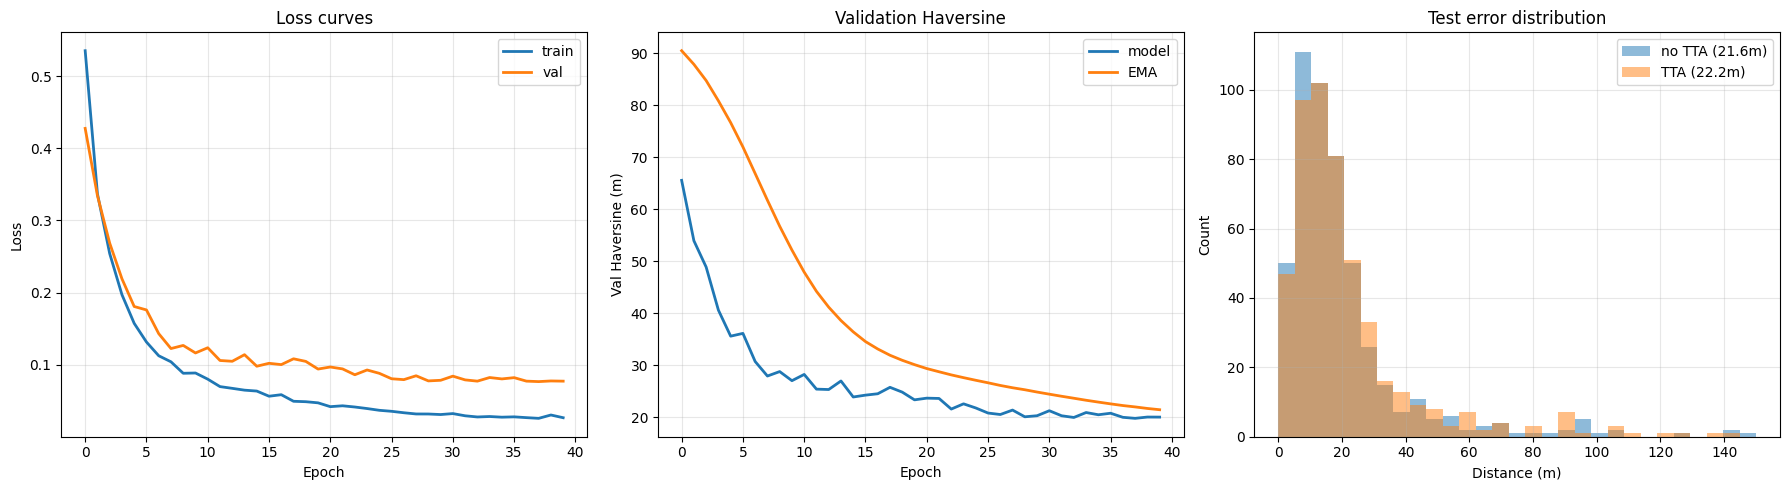

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history["train_loss"], label="train", linewidth=2)
axes[0].plot(history["val_loss"],   label="val",   linewidth=2)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Loss curves"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history["val_haversine"],     label="model",  linewidth=2)
axes[1].plot(history["val_haversine_ema"], label="EMA",    linewidth=2)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Val Haversine (m)")
axes[1].set_title("Validation Haversine"); axes[1].legend(); axes[1].grid(alpha=0.3)

bins = np.linspace(0, 150, 30)
axes[2].hist(test_dists, bins=bins, alpha=0.5, label=f"no TTA ({test_dists.mean():.1f}m)")
axes[2].hist(tta_dists,  bins=bins, alpha=0.5, label=f"TTA ({tta_dists.mean():.1f}m)")
axes[2].set_xlabel("Distance (m)"); axes[2].set_ylabel("Count")
axes[2].set_title("Test error distribution"); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("convnext_refined_curves.png", dpi=150, bbox_inches="tight")
plt.show()

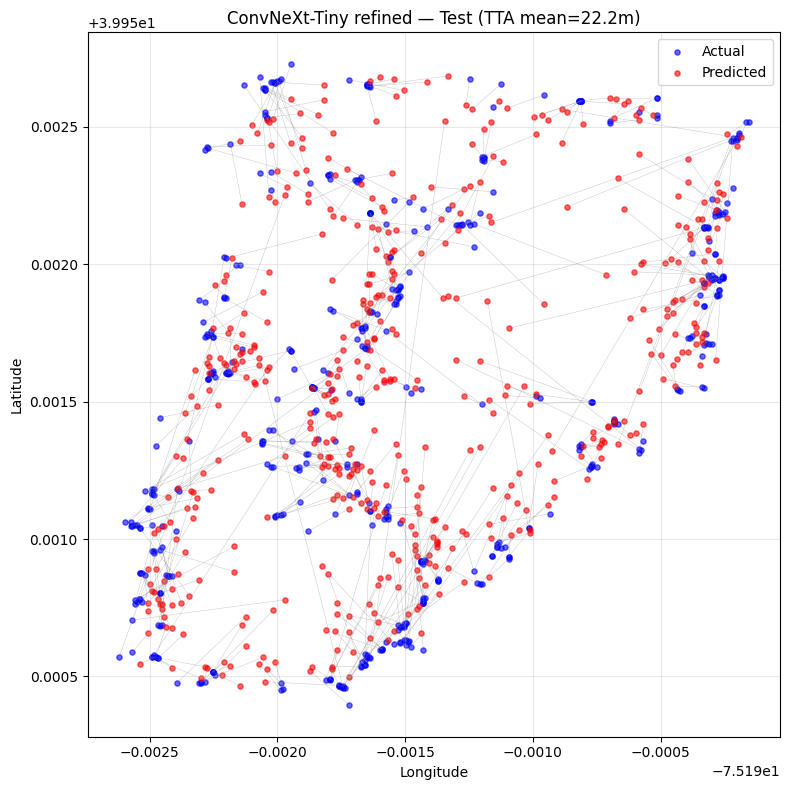

In [ ]:
# predicted vs actual on test (using TTA predictions)
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(tta_actuals[:, 1], tta_actuals[:, 0], c="blue", s=14, alpha=0.6, label="Actual")
ax.scatter(tta_preds[:, 1],   tta_preds[:, 0],   c="red",  s=14, alpha=0.6, label="Predicted")
for i in range(len(tta_actuals)):
    ax.plot([tta_actuals[i, 1], tta_preds[i, 1]],
            [tta_actuals[i, 0], tta_preds[i, 0]],
            color="gray", linewidth=0.3, alpha=0.5)
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title(f"ConvNeXt-Tiny refined — Test (TTA mean={tta_dists.mean():.1f}m)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("convnext_refined_pred_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()